<a href="https://colab.research.google.com/github/viictorsauraa/AprendizajeporRefuerzo_SauraCarmonaCortesGrupo7/blob/main/Entornos_Complejos/SARSA_SG_experiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
if 'google.colab' in str(get_ipython()):
    if not os.path.exists('/content/AprendizajeporRefuerzo_SauraCarmonaCortesGrupo7'):
        !git clone https://github.com/viictorsauraa/AprendizajeporRefuerzo_SauraCarmonaCortesGrupo7.git
    %cd /content/AprendizajeporRefuerzo_SauraCarmonaCortesGrupo7/Entornos_Complejos

# **SARSA Semi-Gradiente en LunarLander-v3**

_Estudio del algoritmo de Diferencia Temporal (TD) On-Policy con Aproximación de Funciones_

Este notebook implementa y analiza el algoritmo **SARSA Semi-Gradiente** sobre el entorno **LunarLander-v3** de Gymnasium. A diferencia de los entornos discretos tradicionales donde se pueden usar tablas $Q$ (como Taxi o FrozenLake), LunarLander cuenta con un espacio de estados continuo (coordenadas, velocidades, ángulos), lo que hace imposible usar una simple matriz. 

Para solucionar esto, utilizamos **aproximación de funciones**: una Red Neuronal Artificial que predice el valor $Q(s, a)$ para cada acción dada una observación del entorno.

### **Características del Agente (SARSA Semi-Gradiente)**
- **Aproximación con Redes Neuronales**: Se utiliza una red neuronal profunda (PyTorch) como "cerebro" para generalizar el aprendizaje de estados continuos similares.
- **Aprendizaje On-Policy**: El agente aprende sobre la misma política que está ejecutando actualmente (incluyendo la exploración $\epsilon$-greedy).
- **Semi-Gradiente**: Se actualizan los pesos de la red usando el gradiente del error de Diferencia Temporal (TD error). Se llama "semi-gradiente" porque ignoramos el efecto del cambio de los pesos en la estimación del estado futuro (el *target* se considera una constante temporal durante el cálculo del gradiente), se rige por la siguiente fórmula:
$$\mathbf{w}_{t+1} = \mathbf{w}_t + \alpha \left[ R_{t+1} + \gamma Q(s_{t+1}, a_{t+1}; \mathbf{w}_t) - Q(s_t, a_t; \mathbf{w}_t) \right] \nabla_{\mathbf{w}} Q(s_t, a_t; \mathbf{w}_t)$$
Donde $\nabla_{\mathbf{w}} Q(s_t, a_t; \mathbf{w}_t)$ es el gradiente de la función de valor con respecto a los pesos de la red
### **El Entorno: LunarLander-v3**
- **Objetivo**: Aterrizar el módulo lunar suavemente en la plataforma de aterrizaje (entre las dos banderas).
- **Estado (8 dimensiones)**: Posición (x, y), velocidad (x, y), ángulo, velocidad angular y dos booleanos que indican si las patas tocan el suelo.
- **Acciones (4 discretas)**: No hacer nada, encender motor izquierdo, encender motor principal, encender motor derecho.
- **Recompensas**: Aterrizar con éxito otorga entre +100 y +140 puntos. Sin embargo, estrellarse resta -100 puntos, y cada instante que el motor principal está encendido cuesta -0.3 puntos mientras que encender los motores laterales cuesta -0.03 puntos. Se considera un entorno resuelto al superar los **+200 puntos** (https://gymnasium.farama.org/environments/box2d/lunar_lander/).
- **Desafío**: El agente debe equilibrar el consumo de combustible con la necesidad de un aterrizaje suave.

## **1. Preparación del Entorno**

La preparación consta de las siguientes partes:
- **Instalación de dependencias**: librería `gymnasium`.
- **Importación de librerías**: `numpy`, `matplotlib`, `tqdm`, `torch`.
- **Creación del entorno LunarLander-v3**: espacio de observación continuo
- **Importación de clases del repositorio**: `SARSASGAgent`, funciones de visualización.

##### _________ **Código de la Instalación e Importación**
----

In [ ]:
%%capture
#@title Instalamos gymnasium
!pip install gymnasium
!pip install "gymnasium[box2d]"

In [6]:
#@title Importamos librerias
import sys
sys.path.insert(0, 'src')

import os
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import gymnasium as gym
import torch
import gc

from agents import SARSASGAgent
from plotting import plot, plot_lengths, show_greedy_episode, print_q_summary, plot_policy_taxi, plot_comparison, plot_lengths_comparison, plot_losses, show_greedy_episode_qnet, frames_to_gif

### Configuramos la semilla para el experimento

In [7]:

# Configuración del dispositivo (CPU o GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")
# Liberación de memoria para evitar problemas de consumo en GPU
gc.collect() # Ejecuta el recolector de basura de Python
torch.cuda.empty_cache() # Vacía la caché de memoria en GPU
# Depuración de errores en CUDA
os.environ['CUDA_LAUNCH_BLOCKING'] = '1' # Muestra errores de CUDA en el punto exacto donde ocurren
# Configuración de la semilla para reproducibilidad
SEED = 2024 # Se define una semilla fija
# Fijar la semilla en NumPy
np.random.seed(SEED) # Para generar números aleatorios consistentes en NumPy
np.random.default_rng(SEED) # Establece una instancia del generador de NumPy con la misma semilla
# Fijar la semilla en Python
os.environ['PYTHONHASHSEED'] = str(SEED) # Evita variabilidad en hashing de Python
# Fijar la semilla en PyTorch
torch.manual_seed(SEED) # Asegura resultados reproducibles en operaciones de PyTorch
if torch.cuda.is_available(): # Si hay GPU disponible
    torch.cuda.manual_seed(SEED) # Fija la semilla para la GPU
    torch.backends.cudnn.deterministic = True # Hace las operaciones de CUDNN determinísticas
    torch.backends.cudnn.benchmark = False # Desactiva optimizaciones de CUDNN para evitar variabilidad

Usando dispositivo: cpu


In [8]:
# Importamos el entorno LunarLander-v3
env = gym.make('LunarLander-v3')
env.reset(seed=SEED)
nS = env.observation_space  
nA = env.action_space      # 6
print(f"Estados: {nS}\nAcciones: {nA}")
print(f"Espacio de estados: {env.observation_space.shape[0]}\nEspacio de acciones: {env.action_space.n}")
# Estado inicial de ejemplo
obs, info = env.reset(seed=SEED)

Estados: Box([ -2.5        -2.5       -10.        -10.         -6.2831855 -10.
  -0.         -0.       ], [ 2.5        2.5       10.        10.         6.2831855 10.
  1.         1.       ], (8,), float32)
Acciones: Discrete(4)
Espacio de estados: 8
Espacio de acciones: 4


## **2. Diseño del Agente: SARSA Semi-Gradiente**

El agente utiliza una red neuronal para estimar los valores $Q(s, a)$. El proceso de actualización sigue la lógica de Diferencia Temporal.

### **Política Epsilon-Greedy**
- **Exploración**: Con probabilidad $\epsilon$, selecciona una acción al azar.
- **Explotación**: Con probabilidad $1-\epsilon$, selecciona la acción con mayor valor $Q$ estimado por la red.
- **Decaimiento**: Si se activa, el valor de $\epsilon$ disminuye gradualmente para que el agente dependa más de su conocimiento a medida que avanza el entrenamiento.

### **Red neuronal parametrizable**
El agente hace uso de la clase `DQN_Network`, que permite cambiar el número de neuronas en una capa oculta así como el número de capas ocultas.

## **3. Experimentación**

### **3.1 Representaciones Gráficas de los Resultados**

Para evaluar el desempeño del agente **SARSA Semi-Gradiente**, analizamos tres métricas fundamentales generadas durante el entrenamiento:

**1. Recompensa media acumulada (Success)**: $f(t) = \frac{\sum_{i=1}^{t} R_i}{t}$. 

En LunarLander, el agente comienza con valores muy negativos (alrededor de -200) debido a choques constantes. 
Buscamos una curva ascendente que supere el umbral de 0 y se acerque a **+200 puntos**, lo que indica que el agente ha aprendido no solo a aterrizar, sino a hacerlo de forma segura y eficiente.

**2. Longitud de los episodios**: Mide el número de pasos (time-steps) que el aterrizador permanece en el aire.
1. **Inicio**: Episodios cortos; el agente cae a plomo y se estrella rápidamente.
2. **Aprendizaje**: La longitud aumenta significativamente (pudiendo llegar a 400-500 pasos) cuando el agente aprende a encender los motores para no chocar, pero aún no sabe aterrizar.
3. **Convergencia**: La longitud se estabiliza (aprox. 250-300 pasos) cuando el agente optimiza el descenso, bajando de forma directa y controlada hacia la plataforma.

**3. Evolución de la Pérdida (Loss)**: Esta gráfica es exclusiva de la aproximación de funciones (Redes Neuronales).

Representa el **Error Cuadrático Medio** entre la predicción de la red $Q(s, a)$ y el objetivo TD.

**Función `show_greedy_episode_qnet`**: Permite visualizar una ejecución del agente con $\epsilon=0$. Aquí verificamos si el piloto ha aprendido la jerarquía de control.

### **3.2 SARSA Semi-Gradiente en LunarLander**

Se entrenan **5,000 episodios** con una política $\epsilon$-greedy con decaimiento exponencial: $\epsilon_{t+1} = \max(\epsilon_{min}, \epsilon_t \times \text{decay})$.

El decaimiento es fundamental en este entorno ya que durante los primeros episodios, un $\epsilon$ cercano a 1 permite que el aterrizador pruebe movimientos aleatorios, descubriendo cómo afectan los motores a la trayectoria sin sesgarse por una red neuronal aún no entrenada. 

A medida que $\epsilon \to 0.01$, el agente deja de tomar acciones erráticas. Esto es importante en LunarLander, ya que para alcanzar los +200 puntos se requiere una precisión milimétrica en el encendido de los motores laterales y el principal justo antes del contacto.

La semilla fijada en el entorno (`env.reset(seed=2024)`) garantiza que la secuencia de terrenos y condiciones iniciales sea reproducible, permitiendo comparar el impacto de diferentes arquitecturas o hiperparámetros.

In [9]:
agent_S = SARSASGAgent(env, epsilon=1, alpha=0.001, discount_factor=0.99, decay=True, weights_path=None, hidden_size=64, num_hidden_layers=2, use_cpu=True)
agent_S.train(num_episodes=5000)
list_stats_S, list_lengths_S, list_losses_S = agent_S.stats()
agent_S.save_model('sarsa_sg_64x64_weights.pth')

Entrenando en: cpu


 10%|█         | 501/5000 [01:28<14:52,  5.04it/s]

success: -50.7320, epsilon: 0.0816, loss: 3471.1511


 20%|██        | 1000/5000 [02:45<06:51,  9.73it/s]

success: 66.8407, epsilon: 0.0100, loss: 1829.6736


...

success: 168.3589, epsilon: 0.0100, loss: 1208.6332


 90%|█████████ | 4503/5000 [10:48<00:40, 12.33it/s]

success: 170.6476, epsilon: 0.0100, loss: 13166.4131


100%|██████████| 5000/5000 [11:53<00:00,  7.01it/s]

success: 176.3803, epsilon: 0.0100, loss: 849.0779


In [10]:
import os, numpy as np
os.makedirs("metrics", exist_ok=True)
np.savez("metrics/sarsa_sg_base.npz", list_stats=list_stats_S, list_lengths=list_lengths_S)


### **3.3 Hiperparámetros de SARSA Semi-Gradiente**

En la aproximación de funciones mediante redes neuronales, el ajuste de los hiperparámetros es crítico para evitar la divergencia y asegurar que el agente asimile correctamente las leyes físicas del entorno.

Para este experimento, nos ceñiremos a ver cómo la arquitectura de la red neuronal afecta a la consecución de los objetivos del agente.
- **Capacidad de la red (`hidden_size`)**: Define la complejidad de las funciones que el agente puede aprender. Aumentar el número de neuronas permite representar mejor la relación entre los 8 sensores de entrada (posición, velocidad, ángulo) y la potencia necesaria en los motores para mantener la estabilidad.
- **Profundidad de la red (`num_hidden_layers`)**: Define el número de capas ocultas entre la entrada (sensores) y la salida (acciones). Una mayor profundidad permite que el agente realice una **abstracción jerárquica**: las primeras capas procesan datos crudos (posición, velocidad), mientras que las capas más profundas pueden inferir conceptos físicos más complejos (como la inercia o la relación entre el ángulo y la gravedad). Sin embargo, para un problema sencillo, añadir demasiadas capas puede resultar contraproducente. Esto aumenta el riesgo de **sobreajuste (overfitting)**, donde la red memoriza trayectorias específicas en lugar de generalizar las leyes físicas. Además, en algoritmos de Diferencia Temporal como SARSA, una red excesivamente profunda puede dificultar la propagación del gradiente o causar **inestabilidad** en las estimaciones de valor, haciendo que el aprendizaje oscile sin converger. 

In [ ]:

agent_S = SARSASGAgent(env, epsilon=1, alpha=0.001, discount_factor=0.99, decay=True, weights_path=None, hidden_size=128, num_hidden_layers=2, use_cpu=True)
agent_S.train(num_episodes=5000)
list_stats_S1, list_lengths_S1, list_losses_S1 = agent_S.stats()
agent_S.save_model('sarsa_sg_128x128_weights.pth')


Entrenando en: cpu


 10%|█         | 500/5000 [02:41<38:18,  1.96it/s]  

success: -52.0771, epsilon: 0.0816, loss: 5420.8174


 20%|██        | 1000/5000 [05:30<26:57,  2.47it/s] 

success: 58.8972, epsilon: 0.0100, loss: 11001.7100


...

success: 160.5045, epsilon: 0.0100, loss: 2186.5964


 90%|█████████ | 4500/5000 [22:13<02:01,  4.11it/s]

success: 167.3759, epsilon: 0.0100, loss: 695.8682


100%|██████████| 5000/5000 [24:21<00:00,  3.42it/s]

success: 173.9267, epsilon: 0.0100, loss: 731.6236


In [ ]:

agent_S = SARSASGAgent(env, epsilon=1, alpha=0.001, discount_factor=0.99, decay=True, weights_path=None, hidden_size=16, num_hidden_layers=2, use_cpu=True)
agent_S.train(num_episodes=5000)
list_stats_S2, list_lengths_S2, list_losses_S2 = agent_S.stats()
agent_S.save_model('sarsa_sg_16x16_weights.pth')

Entrenando en: cpu


 10%|█         | 500/5000 [01:56<26:26,  2.84it/s]

success: -118.4956, epsilon: 0.0816, loss: 422.2677


 20%|██        | 1000/5000 [04:58<28:04,  2.37it/s] 

success: -39.6403, epsilon: 0.0100, loss: 2384.5989


...

success: 94.9835, epsilon: 0.0100, loss: 2463.0408


 90%|█████████ | 4500/5000 [22:40<02:57,  2.82it/s]

success: 100.1341, epsilon: 0.0100, loss: 521.2053


100%|██████████| 5000/5000 [25:21<00:00,  3.29it/s]

success: 106.0212, epsilon: 0.0100, loss: 1335.8494


In [ ]:

agent_S = SARSASGAgent(env, epsilon=1, alpha=0.001, discount_factor=0.99, decay=True, weights_path=None, hidden_size=32, num_hidden_layers=2, use_cpu=True)
agent_S.train(num_episodes=5000)
list_stats_S3, list_lengths_S3, list_losses_S3 = agent_S.stats()
agent_S.save_model('sarsa_sg_32x32_weights.pth')

Entrenando en: cpu


 10%|█         | 501/5000 [02:35<21:50,  3.43it/s]  

success: -41.1296, epsilon: 0.0816, loss: 977.2966


 20%|██        | 1000/5000 [04:53<16:30,  4.04it/s]

success: 23.5636, epsilon: 0.0100, loss: 512.2092


...

success: 140.1010, epsilon: 0.0100, loss: 4970.3853


 90%|█████████ | 4501/5000 [19:23<02:17,  3.63it/s]

success: 144.0783, epsilon: 0.0100, loss: 3050.1238


100%|██████████| 5000/5000 [21:23<00:00,  3.90it/s]

success: 144.5758, epsilon: 0.0100, loss: 2236.3176


In [10]:


agent_S = SARSASGAgent(env, epsilon=1, alpha=0.001, discount_factor=0.99, decay=True, weights_path=None, hidden_size=32, num_hidden_layers=3, use_cpu=True)
agent_S.train(num_episodes=5000)
list_stats_S4, list_lengths_S4, list_losses_S4 = agent_S.stats()
agent_S.save_model('sarsa_sg_32x32x32_weights.pth')

Entrenando en: cpu


 10%|█         | 500/5000 [02:04<30:40,  2.45it/s]  

success: -101.5157, epsilon: 0.0816, loss: 5348.4429


 20%|██        | 1000/5000 [05:13<19:22,  3.44it/s] 

success: 2.0811, epsilon: 0.0100, loss: 1514.3313


...

success: 108.3138, epsilon: 0.0100, loss: 3582.3943


 90%|█████████ | 4501/5000 [23:18<02:01,  4.10it/s]

success: 113.9683, epsilon: 0.0100, loss: 2248.3057


100%|██████████| 5000/5000 [25:51<00:00,  3.22it/s]

success: 118.4385, epsilon: 0.0100, loss: 1.5740


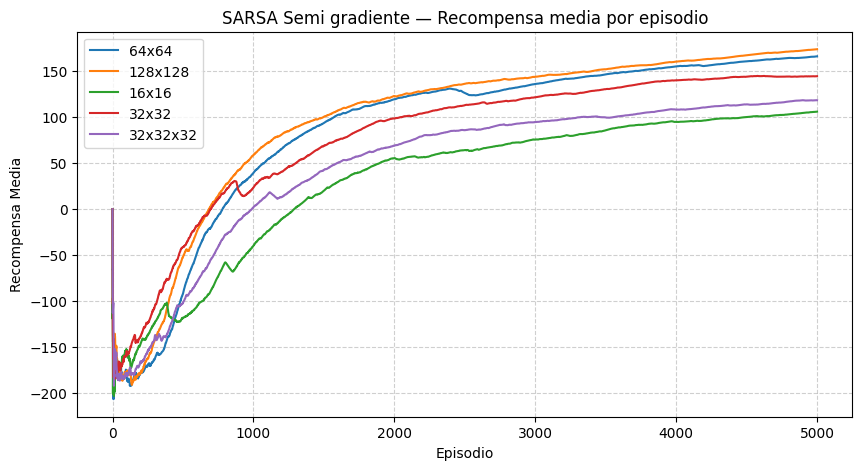

Recompensa media final de 64x64: 166.21
Recompensa media final de 128x128: 173.93
Recompensa media final de 16x16: 106.02
Recompensa media final de 32x32: 144.58
Recompensa media final de 32x32x32: 118.44


In [11]:
#Recompensa media por episodio 
lista_plots_recompensa = [list_stats_S, list_stats_S1, list_stats_S2, list_stats_S3, list_stats_S4]
labels = ['64x64', '128x128', '16x16', '32x32', '32x32x32']
plot_comparison(lista_plots_recompensa, title='SARSA Semi gradiente — Recompensa media por episodio', labels=labels)
for lista, label in zip(lista_plots_recompensa, labels):
    print(f'Recompensa media final de {label}: {lista[-1]:.2f}')

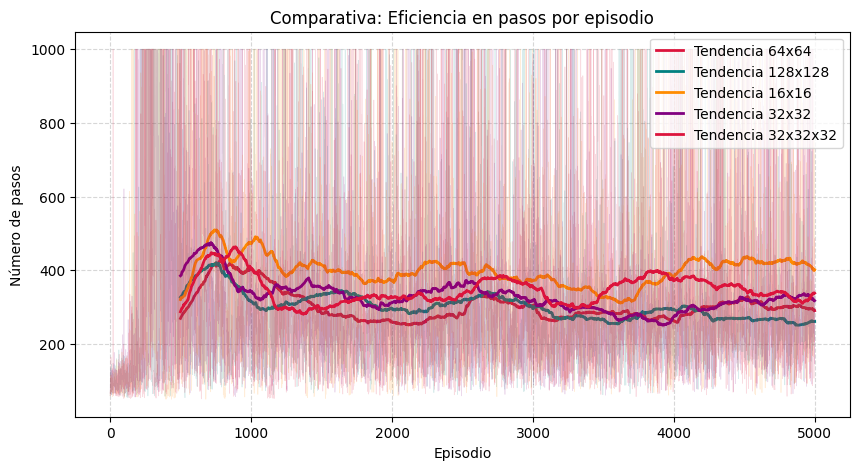

Longitud media final (últimos 1000 episodios) de 64x64: 307.15 pasos
Longitud media final (últimos 1000 episodios) de 128x128: 265.23 pasos
Longitud media final (últimos 1000 episodios) de 16x16: 417.75 pasos
Longitud media final (últimos 1000 episodios) de 32x32: 319.81 pasos
Longitud media final (últimos 1000 episodios) de 32x32x32: 343.42 pasos


In [12]:
#@title Longitud de episodios (on-policy)
lista_plots_longitud = [list_lengths_S, list_lengths_S1, list_lengths_S2, list_lengths_S3, list_lengths_S4]
plot_lengths_comparison(lista_plots_longitud, labels=labels)
for lista, label in zip(lista_plots_longitud, labels):
    print(f'Longitud media final (últimos 1000 episodios) de {label}: {np.mean(lista[-1000:]):.2f} pasos')

c:\Users\guill\Documents\VENV\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


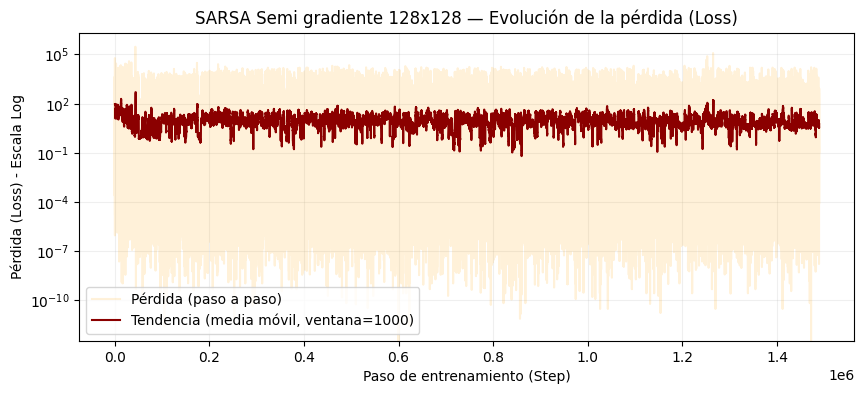

In [15]:
plot_losses(list_losses_S1, title='SARSA Semi gradiente 128x128 — Evolución de la pérdida (Loss)')

### **3.3.1 Análisis de los hiperparámetros**

### **3.3.1 Análisis de Resultados y Comparación de Configuraciones**

En esta sección se evalúa el impacto de los hiperparámetros en el aprendizaje de SARSA. Se han definido cinco configuraciones específicas para cómo observar los distintos hiperparámetros afectan en el desarrollo del entrenamiento en el entorno Lunar Landing:

1.  **Configuración 1 (`hidden_size = 64/num_hidden_layers = 2)`** : Es la configuración estándar que se ha utilizado para el entrenamiento principal. Proporciona una capacidad de representación moderada, permitiendo al agente aprender las relaciones entre los sensores y las acciones sin caer en el sobreajuste. Segunda mejor configuración en términos de recompensa media final (166.21), lo que indica que el agente ha aprendido a aterrizar de manera eficiente.
2. **Configuración 2 (`hidden_size = 128 / num_hidden_layers = 2`)**: Representa la arquitectura con mayor capacidad del experimento, logrando la puntuación más alta de 173.93. Esta red permite una representación mucho más fina y precisa del espacio de estados, lo que se traduce en una navegación excepcionalmente eficiente con el menor número de pasos registrados (265.23). Este resultado demuestra que el agente no solo ha aprendido a aterrizar con seguridad, sino que ha optimizado su trayectoria de descenso de forma profesional.

3. **Configuración 3 (`hidden_size = 16 / num_hidden_layers = 2`)**: Esta versión de capacidad reducida pone de manifiesto las limitaciones de una red excesivamente simple, obteniendo la recompensa más baja de todo el estudio con 106.02 puntos. La falta de neuronas para procesar las ocho dimensiones de entrada obliga al agente a realizar vuelos erráticos y muy prolongados, alcanzando una media de 417.75 pasos, ya que no consigue asimilar la precisión necesaria para un aterrizaje controlado y directo.

4. **Configuración 4 (`hidden_size = 32 / num_hidden_layers = 2`)**: Se sitúa como un término medio en el escalado de la red, alcanzando una recompensa de 144.58 puntos. Aunque muestra una mejora sustancial respecto a la configuración mínima de 16 neuronas, todavía presenta episodios relativamente largos de 319.81 pasos de media. Esto sugiere que, si bien el agente ha aprendido las reglas básicas para no estrellarse, aún no domina la eficiencia técnica necesaria para minimizar el tiempo de vuelo y el gasto de combustible.

5. **Configuración 5 (`hidden_size = 32 / num_hidden_layers = 3`)**: Al introducir una tercera capa oculta se evidencia que la profundidad adicional resulta contraproducente para este problema de control, ya que el rendimiento cae a 118.44 puntos. El aumento de la longitud del episodio a 343.42 pasos respecto a la versión equivalente de dos capas confirma que la red se vuelve más inestable y difícil de entrenar mediante el algoritmo de semi-gradientes, perdiendo capacidad de generalización frente a arquitecturas más anchas pero menos profundas.

En cuanto a la gráfica de recompensa media, se puede ver como todas las configuraciones excepto la más simple y la más profunda logran realizar un aterrizaje exitoso (aunque sin llegar a los 200 puntos). En la gráfica de longitud media por episodio, se puede ver como la configuración con mejor rendimiento según la recompensa media (128x128) es la que tiene la menor longitud media, lo que indica que el agente ha aprendido a aterrizar de forma eficiente. Por otro lado, la configuración con peor rendimiento (16x16) es la que tiene la mayor longitud media, lo que indica que el agente no ha aprendido a aterrizar de forma suave o se queda volando durante mucho tiempo sin conseguir aterrizar.

### **Análisis de la Función de Error (Loss)**

La función de error en SARSA Semi-Gradiente representa el Error Cuadrático Medio (MSE) entre la predicción actual de la red neuronal, $Q(s, a)$, y el objetivo de Diferencia Temporal, definido por la recompensa inmediata más el valor estimado del siguiente estado-acción, $R + \gamma Q(s', a')$. A diferencia del aprendizaje supervisado convencional, donde las etiquetas son estáticas y el error tiende a bajar de forma monótona, en el aprendizaje por refuerzo nos enfrentamos a un "objetivo móvil". Esto ocurre porque el valor que la red intenta alcanzar depende de sus propias estimaciones futuras, las cuales cambian constantemente a medida que los pesos se actualizan. Los picos masivos de pérdida observados en los registros, que llegan a superar las 10,000 unidades, son una manifestación directa de la alta varianza del entorno LunarLander.

## 4. Generación de GIFs

In [7]:
env_demo = gym.make("LunarLander-v3", render_mode='rgb_array')
env_demo.reset(seed=SEED)
weights_path = 'weights/sarsa_sg_128x128_weights.pth'
agent = SARSASGAgent(env_demo, epsilon=0, alpha=0.1, discount_factor=0.99, decay=False, hidden_size=128, num_hidden_layers=2, weights_path=weights_path)

# Ejecutar un episodio utilizando la política greedy y capturar los fotogramas.
frames = show_greedy_episode_qnet(env_demo, agent, max_steps=500)

# Cerrar el entorno una vez terminado el episodio.
env_demo.close()

# Crear el GIF a partir de los fotogramas capturados.
gif_path = frames_to_gif(frames, filename="lunar_lander_sarsa.gif")
print("GIF guardado en:", gif_path)

Entrenando en: cpu
GIF guardado en: lunar_lander_sarsa.gif


## **5. Análisis y Conclusiones**

El experimento realizado con el algoritmo SARSA Semi-Gradiente en el entorno LunarLander permite concluir que la aproximación de funciones mediante redes neuronales es una herramienta eficaz para resolver entornos de control físico donde los métodos tabulares resultan inoperantes debido a la naturaleza continua del espacio de estados. El agente ha demostrado una evolución exitosa al pasar de recompensas iniciales muy negativas a un máximo de 173.93 puntos con la configuración de 128x128 neuronas. Esta mejora sustancial en la puntuación valida la capacidad de la red para asimilar conceptos físicos complejos como la inercia, la gravedad y la aceleración lateral.

### **5.1 Propuestas futuras**

Se podría comparar el rendimiento de SARSA Semi-Gradiente con otros algoritmos de aproximación de funciones, como DQN o actor-crítico, para evaluar si la naturaleza on-policy de SARSA limita su capacidad de aprendizaje en entornos tan complejos como LunarLander.